# Experiment Plots

This notebook renders experiment figures from saved CSV/JSON artifacts only. It does not run raw experiment analysis.

In [10]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Any, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns

FONT_SCALE = 1.45
TITLE_SIZE = 20
LABEL_SIZE = 17
TICK_SIZE = 14
LEGEND_SIZE = 14
ANNOTATION_SIZE = 16

sns.set_theme(style="whitegrid", context="paper", font_scale=FONT_SCALE)
plt.rcParams.update({
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "figure.titlesize": TITLE_SIZE,
})

def find_repo_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repository root from {start}")

ROOT = find_repo_root(Path.cwd())
SAVE_PLOTS = True

EXP1_DIR = ROOT / "experiments/exp1_relevance_bridge/results_llm"
EXP2_DIR = ROOT / "experiments/exp2_iceberg/results"
EXP4_DIR = ROOT / "experiments/exp4_implicature_flow/results"
EXP4_SANKEY_DIR = ROOT / "experiments/exp4_implicature_flow/episode_sankey_html"
EXP5_DIR = ROOT / "experiments/exp5_processing_load/results/sentence-transformers__all-MiniLM-L6-v2"
EXP6_DIR = ROOT / "experiments/exp6_quantity_repair_cascades/results"
EXP7_DIR = ROOT / "experiments/exp7_social_power/results"

EXP2_MIN_PLOT_TRANSITION_ROWS = 1000
EXP6_SAMPLE_CASCADE_COUNT = 18
EXP6_TRIGGER_ORDER = ("under_info", "over_info")
EXP6_TRIGGER_LABELS = {"under_info": "Under-info", "over_info": "Over-info"}
EXP6_TRIGGER_COLORS = {"under_info": "#0f4c5c", "over_info": "#bc6c25"}
EXP6_EVENT_MARKERS = {"repair_event": "o", "challenge_event": "s", "continuation_event": "^", "support_marker": "x", "exit_marker": "D"}
EXP6_EVENT_COLORS = {"repair_event": "#1f77b4", "challenge_event": "#d62728", "continuation_event": "#6a994e", "support_marker": "#7f7f7f", "exit_marker": "#2a9d8f"}
EXP7_ROLE_ORDER = ("guest", "host")
EXP7_VIOLATION_ORDER = ("Quantity", "Relation", "Manner")
EXP7_VIOLATION_SEVERITY = {"Quantity": 1, "Relation": 2, "Manner": 3}

def require_file(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Required plot input is missing: {path}")
    return path

def read_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(require_file(path))

def read_json(path: Path) -> dict[str, Any]:
    with require_file(path).open("r", encoding="utf-8") as handle:
        payload = json.load(handle)
    if not isinstance(payload, dict):
        raise ValueError(f"Expected a JSON object in {path}")
    return payload

def read_exp4_episode_metrics(report: dict[str, Any], path: Path) -> pd.DataFrame:
    if path.exists():
        return read_csv(path)
    rows = report.get("per_episode_metrics")
    if not isinstance(rows, list) or not rows:
        raise ValueError("Exp4 global report does not contain per_episode_metrics for backfilling exp4_episode_metrics.csv.")
    df = pd.DataFrame(rows)
    if SAVE_PLOTS:
        path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(path, index=False)
    return df

def read_exp4_plot_data(path: Path, label: str) -> pd.DataFrame:
    if path.exists():
        return read_csv(path)
    raise FileNotFoundError(
        f"Missing {label}: {path}. Run `python experiments/exp4_implicature_flow/exp4_implicature.py` "
        "once to generate Exp4 plot-data CSVs from the existing analysis code."
    )

def require_columns(df: pd.DataFrame, columns: Sequence[str], label: str) -> None:
    missing = [column for column in columns if column not in df.columns]
    if missing:
        raise ValueError(f"{label} is missing columns: {missing}")

def pdf_path(path: Path) -> Path:
    return path.with_suffix(".pdf")

def save_figure(fig: plt.Figure, path: Path) -> None:
    if SAVE_PLOTS:
        output_path = pdf_path(path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, format="pdf", bbox_inches="tight")

def save_plotly_pdf(fig: go.Figure, path: Path) -> None:
    if SAVE_PLOTS:
        output_path = pdf_path(path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        try:
            fig.write_image(output_path, format="pdf")
        except ValueError as error:
            raise RuntimeError("Plotly PDF export requires the kaleido package from pyproject.toml.") from error

def robust_xlim(values: Sequence[float], lo: float, hi: float, cap: float | None) -> tuple[float, float]:
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if len(finite) == 0:
        raise ValueError("Cannot compute limits for an empty finite array.")
    xmin = float(np.quantile(finite, lo))
    xmax = float(np.quantile(finite, hi))
    if cap is not None:
        xmax = min(float(cap), xmax)
    if xmin == xmax:
        xmax = xmin + 1.0
    return xmin, xmax

def finite_numeric(series: pd.Series) -> np.ndarray:
    values = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
    return values[np.isfinite(values)]


## Exp 1: Relevance Bridge

In [2]:
pair_df = read_csv(EXP1_DIR / "exp1_llm_next_turn_pairs.csv")
category_summary = read_csv(EXP1_DIR / "exp1_llm_next_turn_by_category.csv")
require_columns(pair_df, ["canonical_retained", "true_rank_without_assumptions", "true_rank_with_assumptions"], "Exp1 pair data")
require_columns(category_summary, ["category", "mean_rank_lift", "top1_rate_without_assumptions", "top1_rate_with_assumptions", "mrr_without_assumptions", "mrr_with_assumptions"], "Exp1 category data")

retained = pair_df[pair_df["canonical_retained"] == True].copy()
rank_rows = pd.concat(
    [
        pd.DataFrame({"condition": "Without assumptions", "rank": retained["true_rank_without_assumptions"]}),
        pd.DataFrame({"condition": "With assumptions", "rank": retained["true_rank_with_assumptions"]}),
    ],
    ignore_index=True,
)
fig, ax = plt.subplots(figsize=(10.5, 6.0))
sns.histplot(data=rank_rows, x="rank", hue="condition", multiple="dodge", discrete=True, shrink=0.82, ax=ax)
ax.set_title("Exp 1 LLM True Next-Turn Rank Distribution")
ax.set_xlabel("True Turn Rank")
ax.set_ylabel("Pair Count")
fig.tight_layout()
save_figure(fig, EXP1_DIR / "exp1_llm_rank_distribution.pdf")
plt.show()

ordered = category_summary.sort_values("mean_rank_lift", ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11.0, 6.0))
positions = np.arange(len(ordered))
ax.errorbar(ordered["mean_rank_lift"].astype(float), positions, fmt="o", color="#1b9e77", capsize=3)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1.0)
ax.set_yticks(positions)
ax.set_yticklabels(ordered["category"].astype(str).tolist())
ax.set_title("Exp 1 LLM Assumption Rank Lift by Category")
ax.set_xlabel("Mean Rank Lift")
ax.set_ylabel("Category")
fig.tight_layout()
save_figure(fig, EXP1_DIR / "exp1_llm_rank_lift_by_category.pdf")
plt.show()

rows = []
for summary_row in category_summary.itertuples(index=False):
    rows.extend([
        {"category": summary_row.category, "metric": "Top-1 without assumptions", "value": summary_row.top1_rate_without_assumptions},
        {"category": summary_row.category, "metric": "Top-1 with assumptions", "value": summary_row.top1_rate_with_assumptions},
        {"category": summary_row.category, "metric": "MRR without assumptions", "value": summary_row.mrr_without_assumptions},
        {"category": summary_row.category, "metric": "MRR with assumptions", "value": summary_row.mrr_with_assumptions},
    ])
fig, ax = plt.subplots(figsize=(12.0, 6.5))
sns.barplot(data=pd.DataFrame(rows), x="category", y="value", hue="metric", ax=ax)
ax.set_title("Exp 1 LLM Top-1 and MRR by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Value")
ax.tick_params(axis="x", rotation=30)
ax.legend(frameon=False, loc="best")
fig.tight_layout()
save_figure(fig, EXP1_DIR / "exp1_llm_top1_mrr_by_category.pdf")
plt.show()


FileNotFoundError: Required plot input is missing: /home/edenzha/flow_of_argument/experiments/exp1_relevance_bridge/results_llm/exp1_llm_next_turn_pairs.csv

## Exp 2: Iceberg

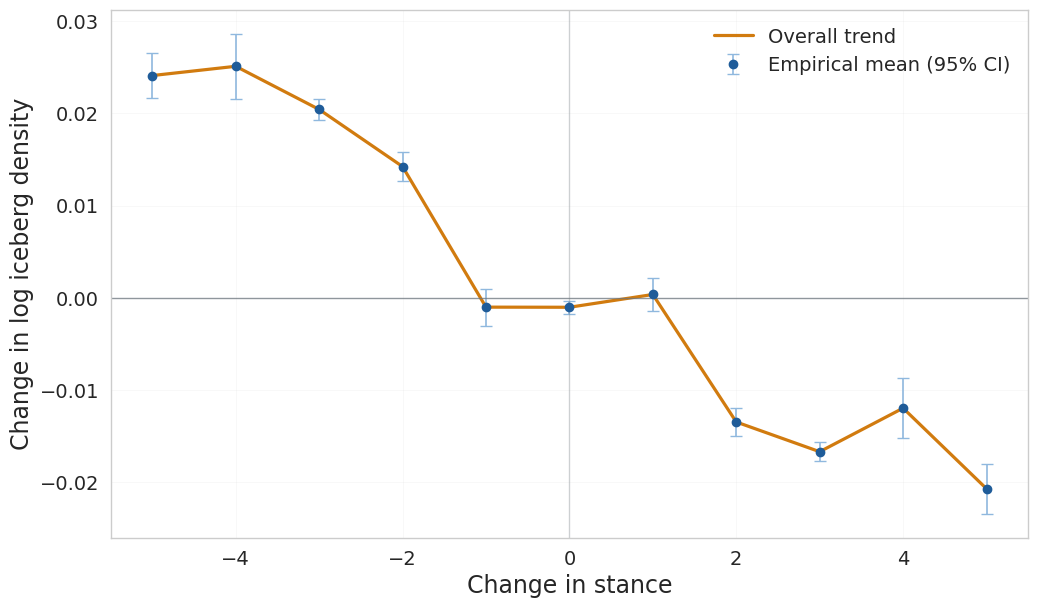

In [3]:
bins_df = read_csv(EXP2_DIR / "exp2_local_effect_bins.csv")
require_columns(bins_df, ["delta_stance_pt", "n_transition_rows", "mean_delta_log_iceberg_density", "ci_low_delta_log_iceberg_density", "ci_high_delta_log_iceberg_density"], "Exp2 local effect bins")
plot_df = bins_df[bins_df["n_transition_rows"].astype(int) >= EXP2_MIN_PLOT_TRANSITION_ROWS].copy()
if plot_df.empty:
    raise ValueError(f"No Exp2 bins meet the minimum row threshold: {EXP2_MIN_PLOT_TRANSITION_ROWS}")

x_values = plot_df["delta_stance_pt"].astype(float).to_numpy()
y_values = plot_df["mean_delta_log_iceberg_density"].astype(float).to_numpy()
lower_values = plot_df["ci_low_delta_log_iceberg_density"].astype(float).to_numpy()
upper_values = plot_df["ci_high_delta_log_iceberg_density"].astype(float).to_numpy()
fig, ax = plt.subplots(figsize=(10.6, 6.3))
ax.errorbar(x_values, y_values, yerr=np.vstack([y_values - lower_values, upper_values - y_values]), fmt="o", color="#1f5c99", ecolor="#8fb8de", elinewidth=1.2, capsize=4, markersize=6, label="Empirical mean (95% CI)")
ax.plot(x_values, y_values, color="#d17b0f", linewidth=2.3, label="Overall trend")
ax.axhline(0.0, color="#6c757d", linewidth=1.0, alpha=0.75)
ax.axvline(0.0, color="#6c757d", linewidth=1.0, alpha=0.30)
ax.set_xlabel("Change in stance")
ax.set_ylabel("Change in log iceberg density")
ax.legend(frameon=False, loc="best", fontsize=LEGEND_SIZE)
ax.grid(alpha=0.16, linewidth=0.6)
fig.tight_layout()
save_figure(fig, EXP2_DIR / "exp2_local_relationship.pdf")
plt.show()


## Exp 4: Implicature Flow

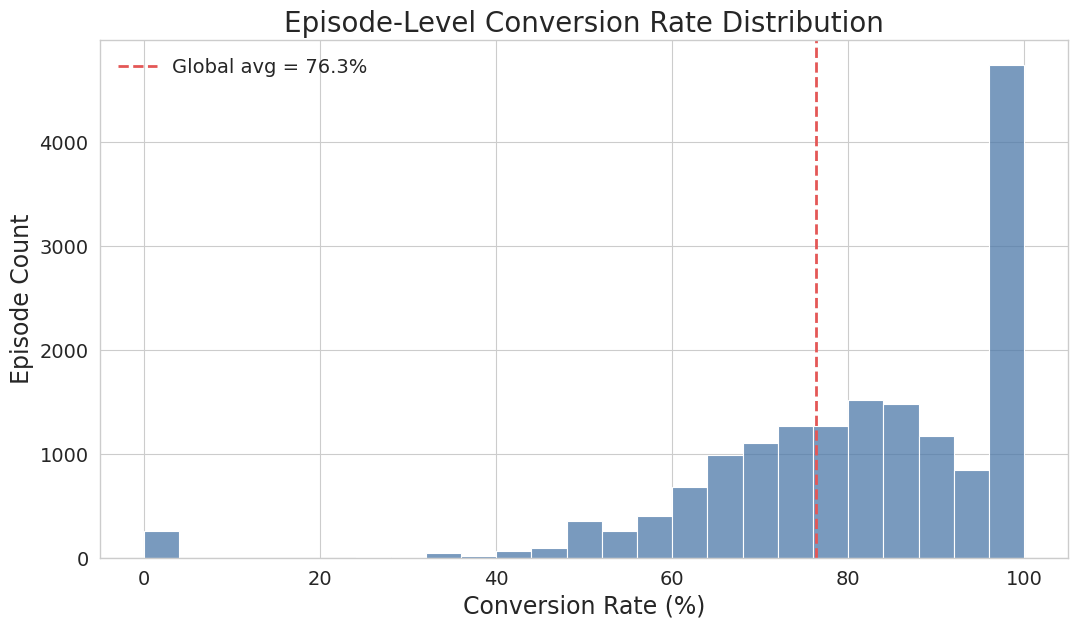

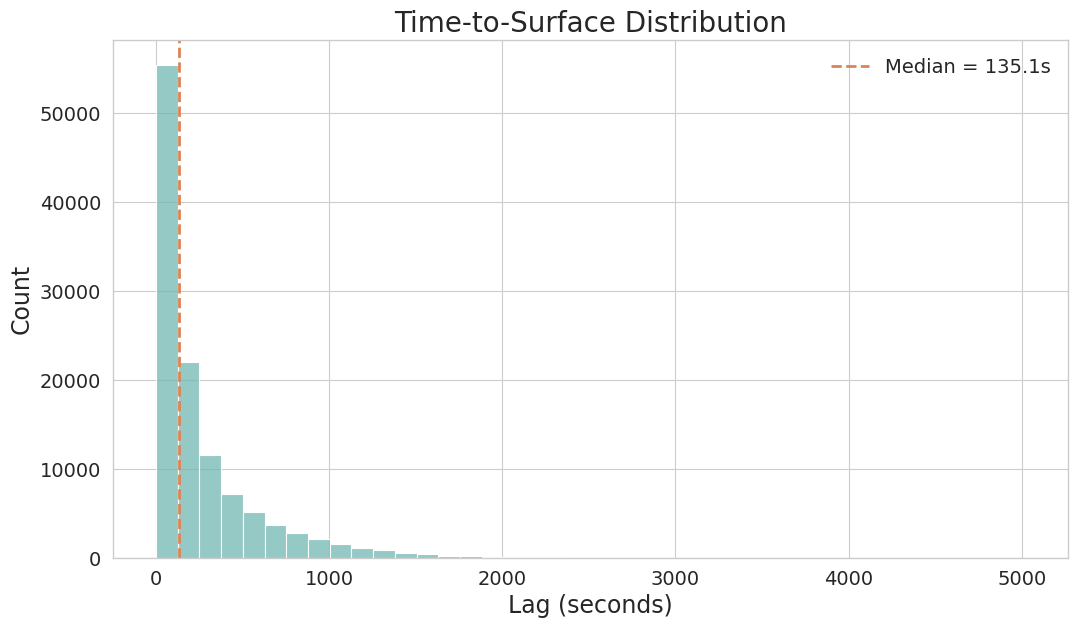

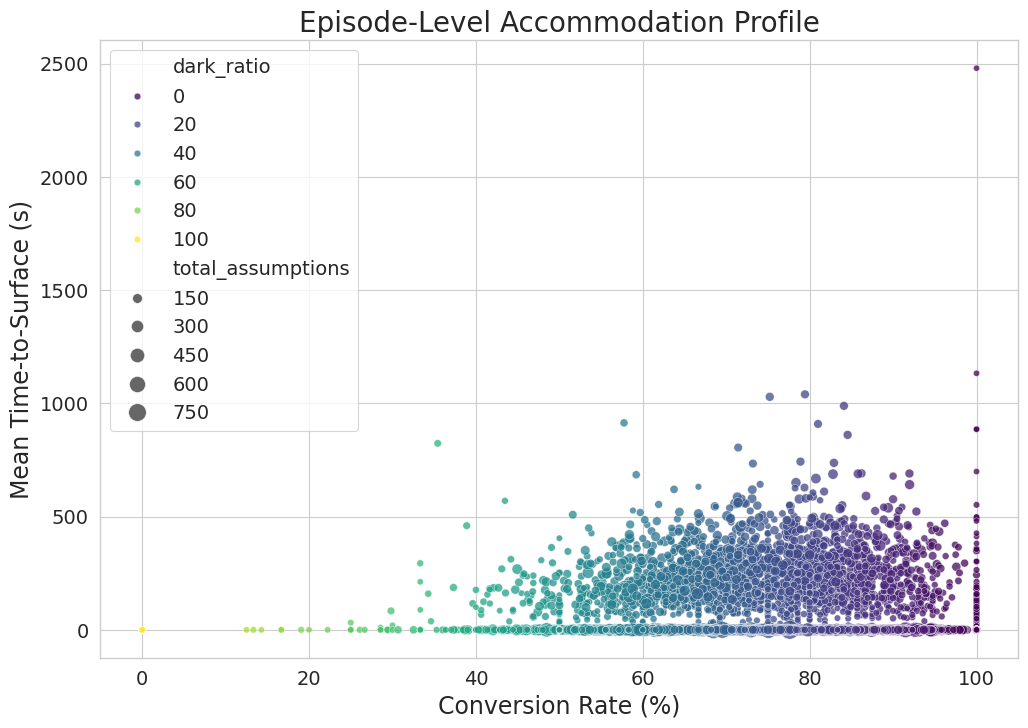

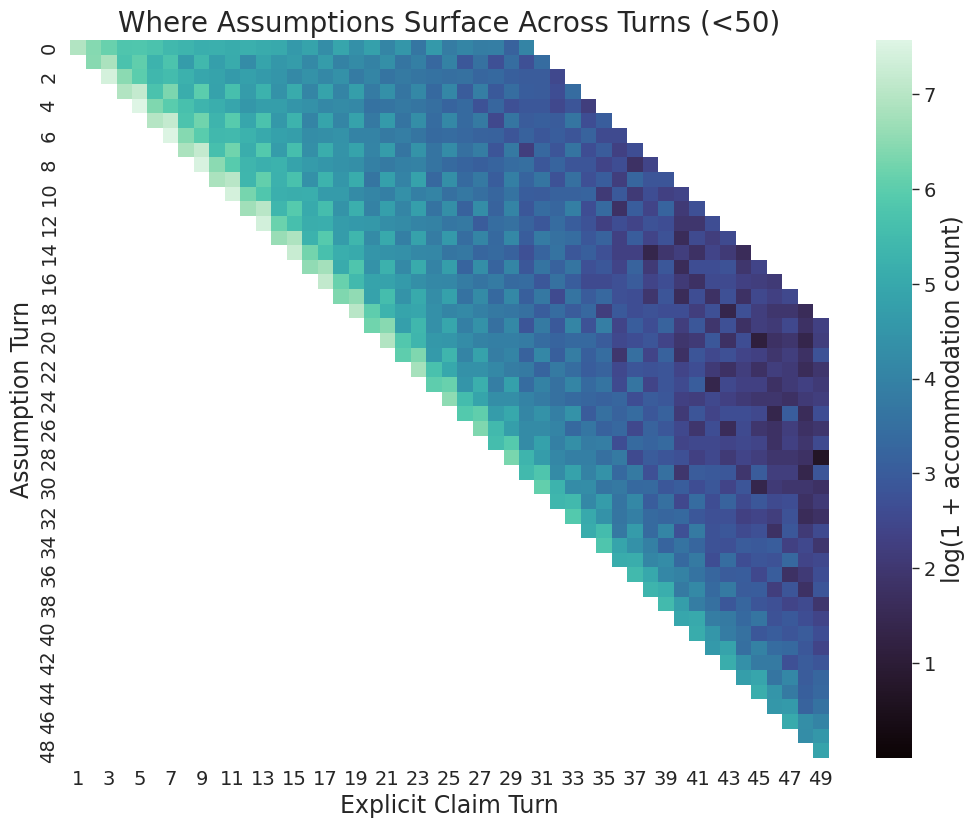

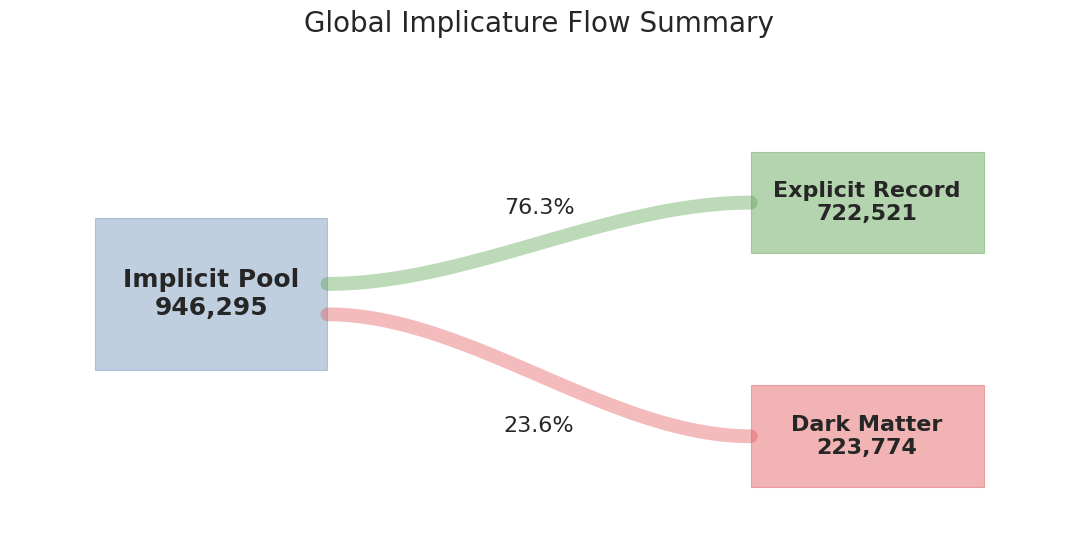

In [12]:
exp4_report = read_json(EXP4_DIR / "implicature_flow_global_report.json")
episode_df = read_exp4_episode_metrics(exp4_report, EXP4_DIR / "exp4_episode_metrics.csv")
lag_df = read_exp4_plot_data(EXP4_DIR / "exp4_lag_samples.csv", "Exp4 lag samples")
flow_df = read_exp4_plot_data(EXP4_DIR / "exp4_flow_edges.csv", "Exp4 flow edges")
require_columns(episode_df, ["episode_id", "total_assumptions", "dark_matter", "conversion_rate", "mean_lag"], "Exp4 episode metrics")
require_columns(lag_df, ["episode_id", "lag_seconds"], "Exp4 lag samples")
require_columns(flow_df, ["episode_id", "source_turn", "target_turn", "count", "mean_lag_seconds"], "Exp4 flow edges")

global_metrics = exp4_report["global_metrics"]
global_conv = float(global_metrics["conversion_rate_percent"])
lag_stats = global_metrics["lag_distribution_seconds"]

fig, ax = plt.subplots(figsize=(11.0, 6.5))
sns.histplot(episode_df["conversion_rate"], bins=25, color="#4C78A8", edgecolor="white", ax=ax)
ax.axvline(global_conv, color="#E45756", linestyle="--", linewidth=2, label=f"Global avg = {global_conv:.1f}%")
ax.set_title("Episode-Level Conversion Rate Distribution")
ax.set_xlabel("Conversion Rate (%)")
ax.set_ylabel("Episode Count")
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, EXP4_DIR / "conversion_rate_distribution.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(11.0, 6.5))
sns.histplot(lag_df["lag_seconds"], bins=40, color="#72B7B2", edgecolor="white", ax=ax)
ax.axvline(float(lag_stats["median"]), color="#DD8452", linestyle="--", linewidth=2, label=f"Median = {float(lag_stats['median']):.1f}s")
ax.set_title("Time-to-Surface Distribution")
ax.set_xlabel("Lag (seconds)")
ax.set_ylabel("Count")
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, EXP4_DIR / "lag_distribution.pdf")
plt.show()

scatter_df = episode_df.copy()
scatter_df["dark_ratio"] = 100.0 * scatter_df["dark_matter"] / scatter_df["total_assumptions"].clip(lower=1)
fig, ax = plt.subplots(figsize=(10.5, 7.5))
sns.scatterplot(data=scatter_df, x="conversion_rate", y="mean_lag", size="total_assumptions", hue="dark_ratio", palette="viridis", sizes=(20, 180), alpha=0.75, ax=ax)
ax.set_title("Episode-Level Accommodation Profile")
ax.set_xlabel("Conversion Rate (%)")
ax.set_ylabel("Mean Time-to-Surface (s)")
fig.tight_layout()
save_figure(fig, EXP4_DIR / "episode_accommodation_profile.pdf")
plt.show()

heat = flow_df.groupby(["source_turn", "target_turn"], as_index=False)["count"].sum()
if heat.empty:
    raise ValueError("Exp4 flow edges are empty; cannot render heatmap.")
heat = heat[(heat["source_turn"] < 50) & (heat["target_turn"] < 50)].copy()
if heat.empty:
    raise ValueError("Exp4 heatmap has no flow edges with both turns less than 50.")
pivot = heat.pivot(index="source_turn", columns="target_turn", values="count").fillna(0)
if pivot.empty:
    raise ValueError("Exp4 heatmap pivot is empty after caps.")
fig, ax = plt.subplots(figsize=(10.5, 8.5))
cmap = sns.color_palette("mako", as_cmap=True)
cmap.set_under("white")
sns.heatmap(np.log1p(pivot), cmap=cmap, vmin=1e-9, ax=ax, cbar_kws={"label": "log(1 + accommodation count)"})
ax.set_title("Where Assumptions Surface Across Turns (<50)")
ax.set_xlabel("Explicit Claim Turn")
ax.set_ylabel("Assumption Turn")
fig.tight_layout()
save_figure(fig, EXP4_DIR / "turn_lag_heatmap.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(11.0, 5.8))
total = int(global_metrics["total_assumptions"])
accommodated = int(global_metrics["total_accommodated"])
dark = int(global_metrics["dark_matter_count"])
ax.add_patch(plt.Rectangle((0.08, 0.35), 0.22, 0.3, color="#4C78A8", alpha=0.35))
ax.add_patch(plt.Rectangle((0.70, 0.58), 0.22, 0.2, color="#59A14F", alpha=0.45))
ax.add_patch(plt.Rectangle((0.70, 0.12), 0.22, 0.2, color="#E15759", alpha=0.45))
ax.text(0.19, 0.5, f"Implicit Pool\n{total:,}", ha="center", va="center", fontsize=ANNOTATION_SIZE + 2, weight="bold")
ax.text(0.81, 0.68, f"Explicit Record\n{accommodated:,}", ha="center", va="center", fontsize=ANNOTATION_SIZE, weight="bold")
ax.text(0.81, 0.22, f"Dark Matter\n{dark:,}", ha="center", va="center", fontsize=ANNOTATION_SIZE, weight="bold")
for y0, y1, color in [(0.52, 0.68, "#59A14F"), (0.46, 0.22, "#E15759")]:
    path_x = np.linspace(0.30, 0.70, 80)
    t = np.linspace(0, 1, 80)
    ease = 3 * t**2 - 2 * t**3
    ax.plot(path_x, y0 + (y1 - y0) * ease, color=color, linewidth=10, alpha=0.4, solid_capstyle="round")
ax.text(0.50, 0.67, f"{float(global_metrics['conversion_rate_percent']):.1f}%", ha="center", va="center", fontsize=ANNOTATION_SIZE, bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "none", "alpha": 0.85})
ax.text(0.50, 0.24, f"{float(global_metrics['dark_matter_ratio_percent']):.1f}%", ha="center", va="center", fontsize=ANNOTATION_SIZE, bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "none", "alpha": 0.85})
ax.set_title("Global Implicature Flow Summary")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
fig.tight_layout()
save_figure(fig, EXP4_DIR / "global_implicature_flow_summary.pdf")
plt.show()


In [5]:
EXP4_SANKEY_LIMIT = 50
if flow_df.empty:
    raise ValueError("Exp4 flow edges are empty; cannot render Sankey diagrams.")

for episode_id in sorted(flow_df["episode_id"].astype(str).unique())[:EXP4_SANKEY_LIMIT]:
    episode_edges = flow_df[flow_df["episode_id"].astype(str) == episode_id].copy()
    turns = sorted(set(episode_edges["source_turn"].astype(int)) | set(episode_edges["target_turn"].astype(int)))
    if not turns:
        raise ValueError(f"Exp4 episode has no turn nodes for Sankey: {episode_id}")
    n_turns = len(turns)
    y_positions = [0.5] if n_turns == 1 else list(np.linspace(0.95, 0.05, n_turns))
    palette = sns.color_palette("husl", n_turns)
    turn_colors = {turn: f"rgba({int(r * 255)},{int(g * 255)},{int(b * 255)},0.65)" for turn, (r, g, b) in zip(turns, palette)}
    labels = [f"A{turn}" for turn in turns] + [f"C{turn}" for turn in turns]
    lookup = {("A", turn): index for index, turn in enumerate(turns)}
    lookup.update({("C", turn): index + n_turns for index, turn in enumerate(turns)})
    sources = [lookup[("A", int(row.source_turn))] for row in episode_edges.itertuples(index=False)]
    targets = [lookup[("C", int(row.target_turn))] for row in episode_edges.itertuples(index=False)]
    values = episode_edges["count"].astype(int).tolist()
    link_colors = [turn_colors[int(row.source_turn)] for row in episode_edges.itertuples(index=False)]
    customdata = episode_edges[["mean_lag_seconds", "count"]].astype(float).to_numpy()
    fig = go.Figure(go.Sankey(arrangement="fixed", node={"pad": 10, "thickness": 12, "line": {"color": "rgba(80,80,80,0.35)", "width": 0.5}, "label": labels, "color": [turn_colors[turn] for turn in turns] + ["rgba(170,170,170,0.85)"] * n_turns, "x": [0.08] * n_turns + [0.92] * n_turns, "y": y_positions + y_positions, "hovertemplate": "%{label}<extra></extra>"}, link={"source": sources, "target": targets, "value": values, "color": link_colors, "customdata": customdata, "hovertemplate": "From %{source.label} to %{target.label}<br>Count: %{value}<br>Mean lag: %{customdata[0]:.1f}s<extra></extra>"}))
    fig.update_layout(title={"text": f"Episode {episode_id} Implicature Flow", "font": {"size": TITLE_SIZE}}, font={"size": TICK_SIZE}, width=1100, height=max(550, int(26 * n_turns + 220)), margin={"l": 40, "r": 40, "t": 80, "b": 30})
    if SAVE_PLOTS:
        EXP4_SANKEY_DIR.mkdir(parents=True, exist_ok=True)
        save_plotly_pdf(fig, EXP4_SANKEY_DIR / f"sankey_{episode_id}.pdf")
    fig.show()


NameError: name 'flow_df' is not defined

## Exp 5: Processing Load

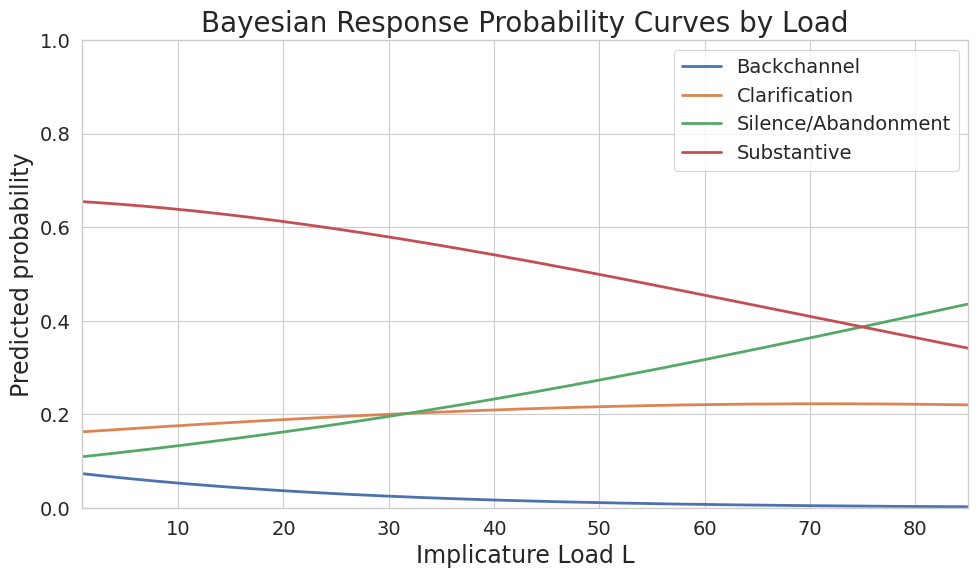

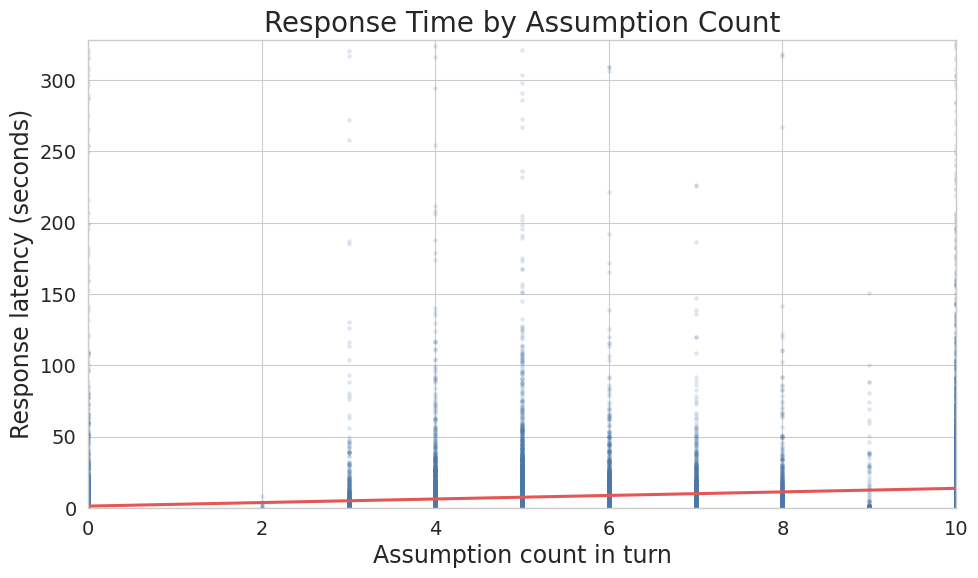

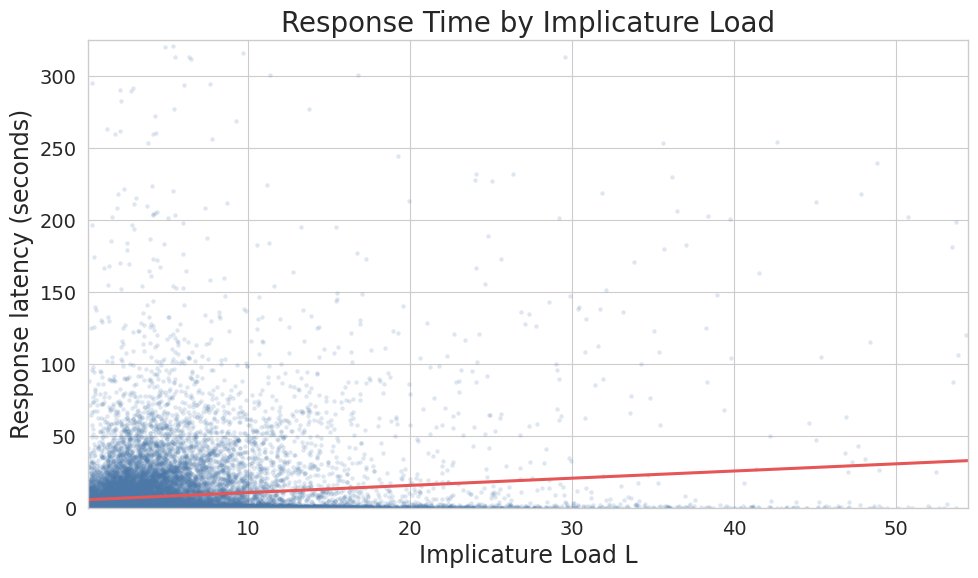

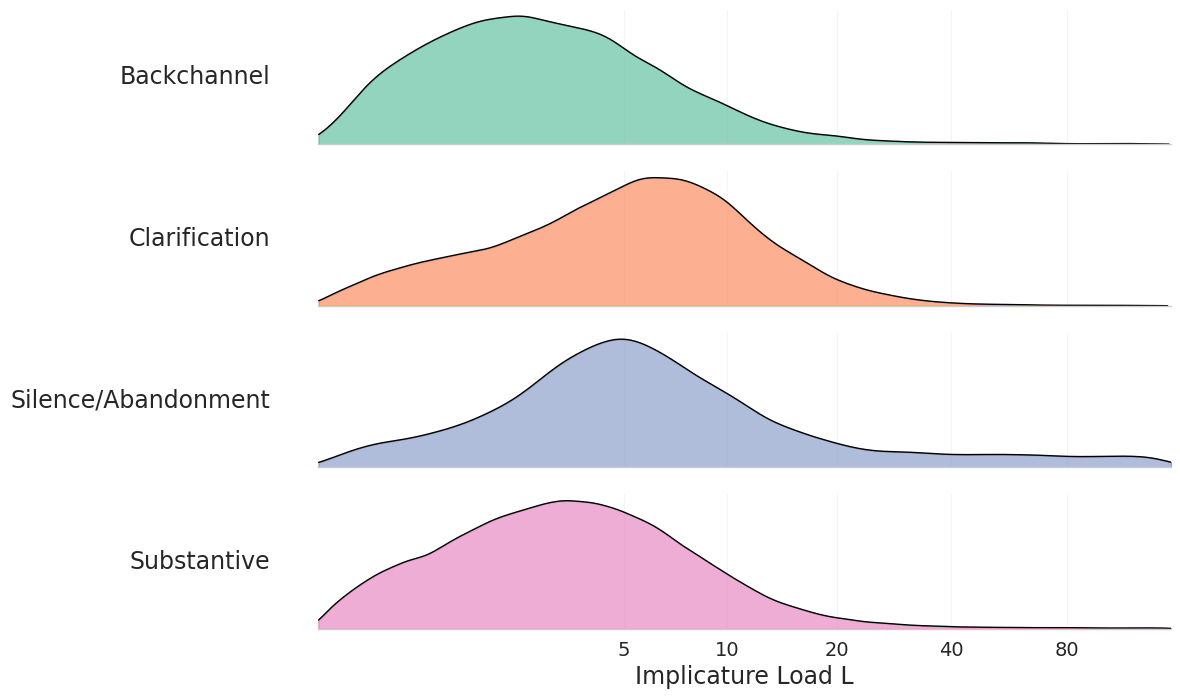

In [6]:
turn_df = read_csv(EXP5_DIR / "exp5_turn_level_features.csv")
curve_df = read_csv(EXP5_DIR / "exp5_probability_curves.csv")
counts_df = read_csv(EXP5_DIR / "exp5_response_type_counts.csv")
require_columns(turn_df, ["assumption_count_in_turn", "gap_to_next_sec", "implicature_load", "next_response_type"], "Exp5 turn features")
require_columns(curve_df, ["implicature_load"], "Exp5 probability curves")
require_columns(counts_df, ["response_type", "count"], "Exp5 response counts")

fig, ax = plt.subplots(figsize=(10.0, 6.0))
x = curve_df["implicature_load"].astype(float).to_numpy()
xmin, xmax = robust_xlim(x, 0.01, 0.99, None)
for column in sorted(column for column in curve_df.columns if column.startswith("p_")):
    sns.lineplot(x=x, y=curve_df[column].astype(float).to_numpy(), linewidth=2.0, label=column.replace("p_", ""), ax=ax)
ax.set_title("Bayesian Response Probability Curves by Load")
ax.set_xlabel("Implicature Load L")
ax.set_ylabel("Predicted probability")
ax.set_ylim(0, 1)
ax.set_xlim(xmin, xmax)
ax.legend()
fig.tight_layout()
save_figure(fig, EXP5_DIR / "exp5_probability_curves.pdf")
plt.show()

for x_column, title, xlabel, output_name in [
    ("assumption_count_in_turn", "Response Time by Assumption Count", "Assumption count in turn", "exp5_assumption_count_vs_response_time.pdf"),
    ("implicature_load", "Response Time by Implicature Load", "Implicature Load L", "exp5_implicature_load_vs_response_time.pdf"),
]:
    pairs = turn_df[[x_column, "gap_to_next_sec"]].apply(pd.to_numeric, errors="coerce").dropna()
    pairs = pairs[pairs["gap_to_next_sec"] >= 0]
    if len(pairs) < 3:
        raise ValueError(f"Exp5 scatter has fewer than 3 finite rows for {x_column}.")
    x_values = pairs[x_column].to_numpy(dtype=float)
    y_values = pairs["gap_to_next_sec"].to_numpy(dtype=float)
    xmin, xmax = robust_xlim(x_values, 0.01, 0.99, None)
    ymin, ymax = robust_xlim(y_values, 0.0, 0.995, 2000.0)
    mask = np.isfinite(x_values) & np.isfinite(y_values) & (x_values >= xmin) & (x_values <= xmax) & (y_values >= ymin) & (y_values <= ymax)
    x_values = x_values[mask]
    y_values = y_values[mask]
    if len(x_values) < 3:
        raise ValueError(f"Exp5 scatter has fewer than 3 visible rows for {x_column}.")
    rng = np.random.default_rng(42)
    if len(x_values) > 30000:
        keep = rng.choice(len(x_values), size=30000, replace=False)
        x_plot = x_values[keep]
        y_plot = y_values[keep]
    else:
        x_plot = x_values
        y_plot = y_values
    fig, ax = plt.subplots(figsize=(10.0, 6.0))
    sns.scatterplot(x=x_plot, y=y_plot, s=10, alpha=0.18, linewidth=0, color="#4C78A8", ax=ax)
    sns.regplot(x=x_values, y=y_values, scatter=False, ci=None, line_kws={"color": "#E45756", "linewidth": 2.2}, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Response latency (seconds)")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    fig.tight_layout()
    save_figure(fig, EXP5_DIR / output_name)
    plt.show()

response_order = counts_df["response_type"].astype(str).tolist()
by_class = {}
for response_type in response_order:
    values = pd.to_numeric(turn_df.loc[turn_df["next_response_type"].astype(str) == response_type, "implicature_load"], errors="coerce").dropna().astype(float).to_numpy()
    values = values[np.isfinite(values)]
    if len(values) >= 5:
        by_class[response_type] = values
if not by_class:
    raise ValueError("Exp5 ridge plot has no response classes with at least 5 finite load values.")
all_values = np.concatenate(list(by_class.values()))
xmin, xmax = robust_xlim(np.log1p(all_values), 0.0, 0.995, None)
fig, axes = plt.subplots(len(by_class), 1, figsize=(11.0, 1.8 * len(by_class)), sharex=True)
axes = [axes] if len(by_class) == 1 else list(axes)
colors = sns.color_palette("Set2", len(by_class))
for axis, (response_type, values), color in zip(axes, by_class.items(), colors):
    plot_values = np.log1p(values)
    visible = plot_values[(plot_values >= xmin) & (plot_values <= xmax)]
    if len(visible) < 5:
        visible = plot_values
    sns.kdeplot(x=visible, fill=True, alpha=0.7, linewidth=1.0, color=color, cut=0, clip=(xmin, xmax), ax=axis)
    sns.kdeplot(x=visible, fill=False, linewidth=1.0, color="black", cut=0, clip=(xmin, xmax), ax=axis)
    axis.set_ylabel(response_type, rotation=0, ha="right", va="center", labelpad=35)
    axis.set_yticks([])
    axis.grid(axis="x", alpha=0.2)
    for spine in ("top", "right", "left"):
        axis.spines[spine].set_visible(False)
    axis.set_xlim(xmin, xmax)
raw_ticks = np.asarray([0, 5, 10, 20, 40, 80, 160, 320, 640, 1280], dtype=float)
ticks = np.log1p(raw_ticks)
visible_ticks = ticks[(ticks >= xmin) & (ticks <= xmax)]
axes[-1].set_xticks(visible_ticks)
axes[-1].set_xticklabels([str(int(round(np.expm1(value)))) for value in visible_ticks])
axes[-1].set_xlabel("Implicature Load L")
fig.subplots_adjust(bottom=0.12, top=0.98)
save_figure(fig, EXP5_DIR / "exp5_load_ridge_by_response_type.pdf")
plt.show()


## Exp 6: Quantity Repair Cascades

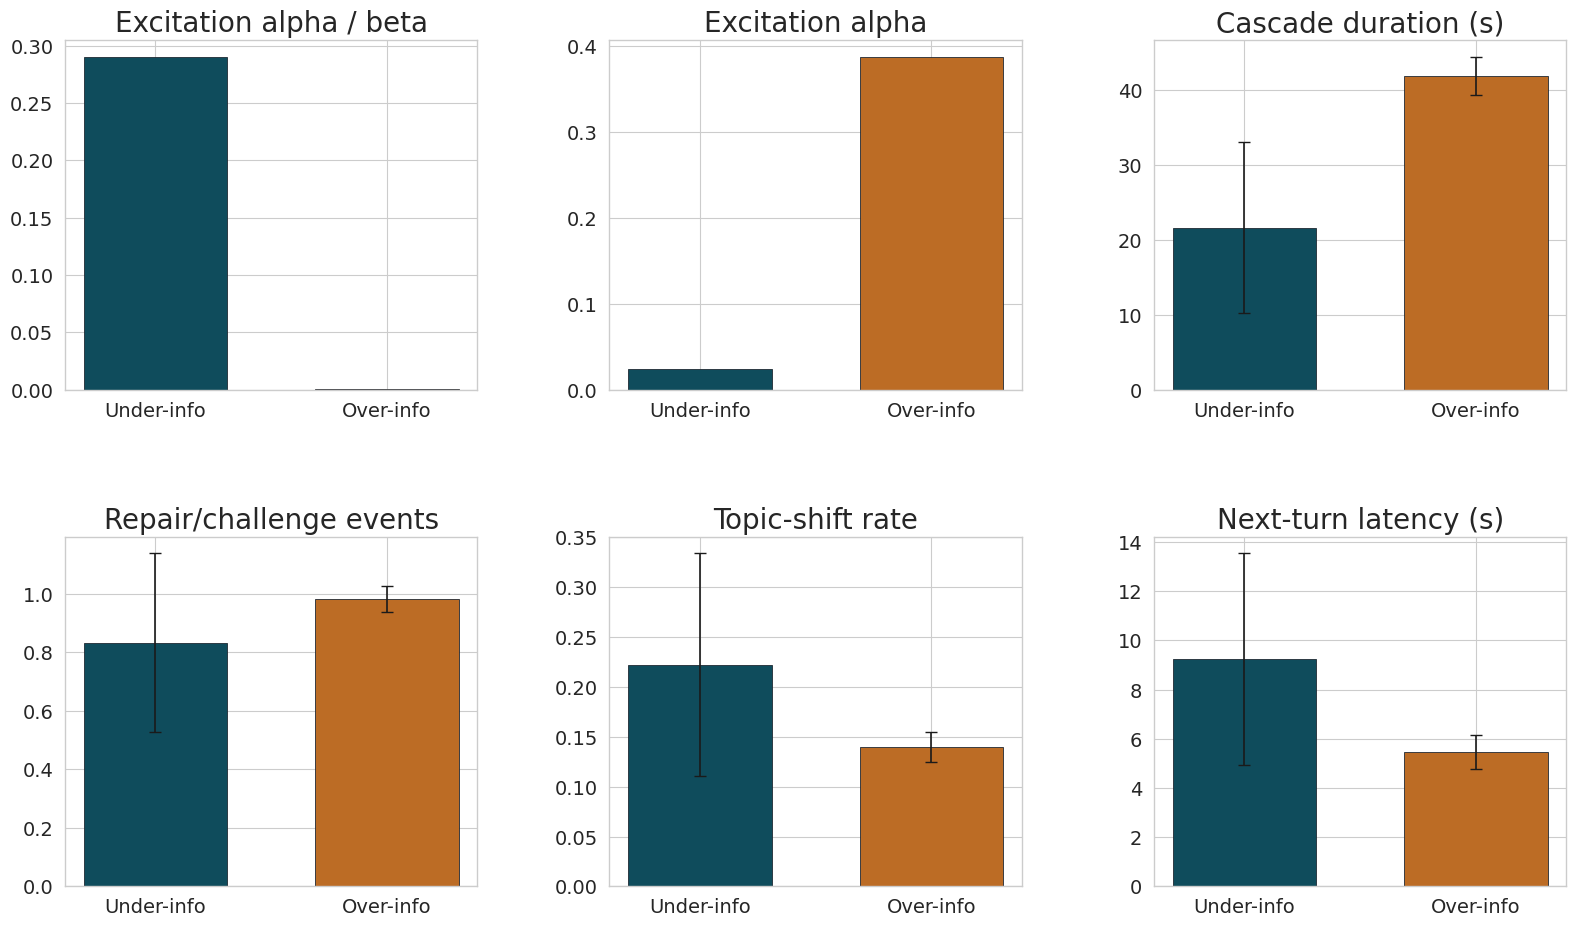

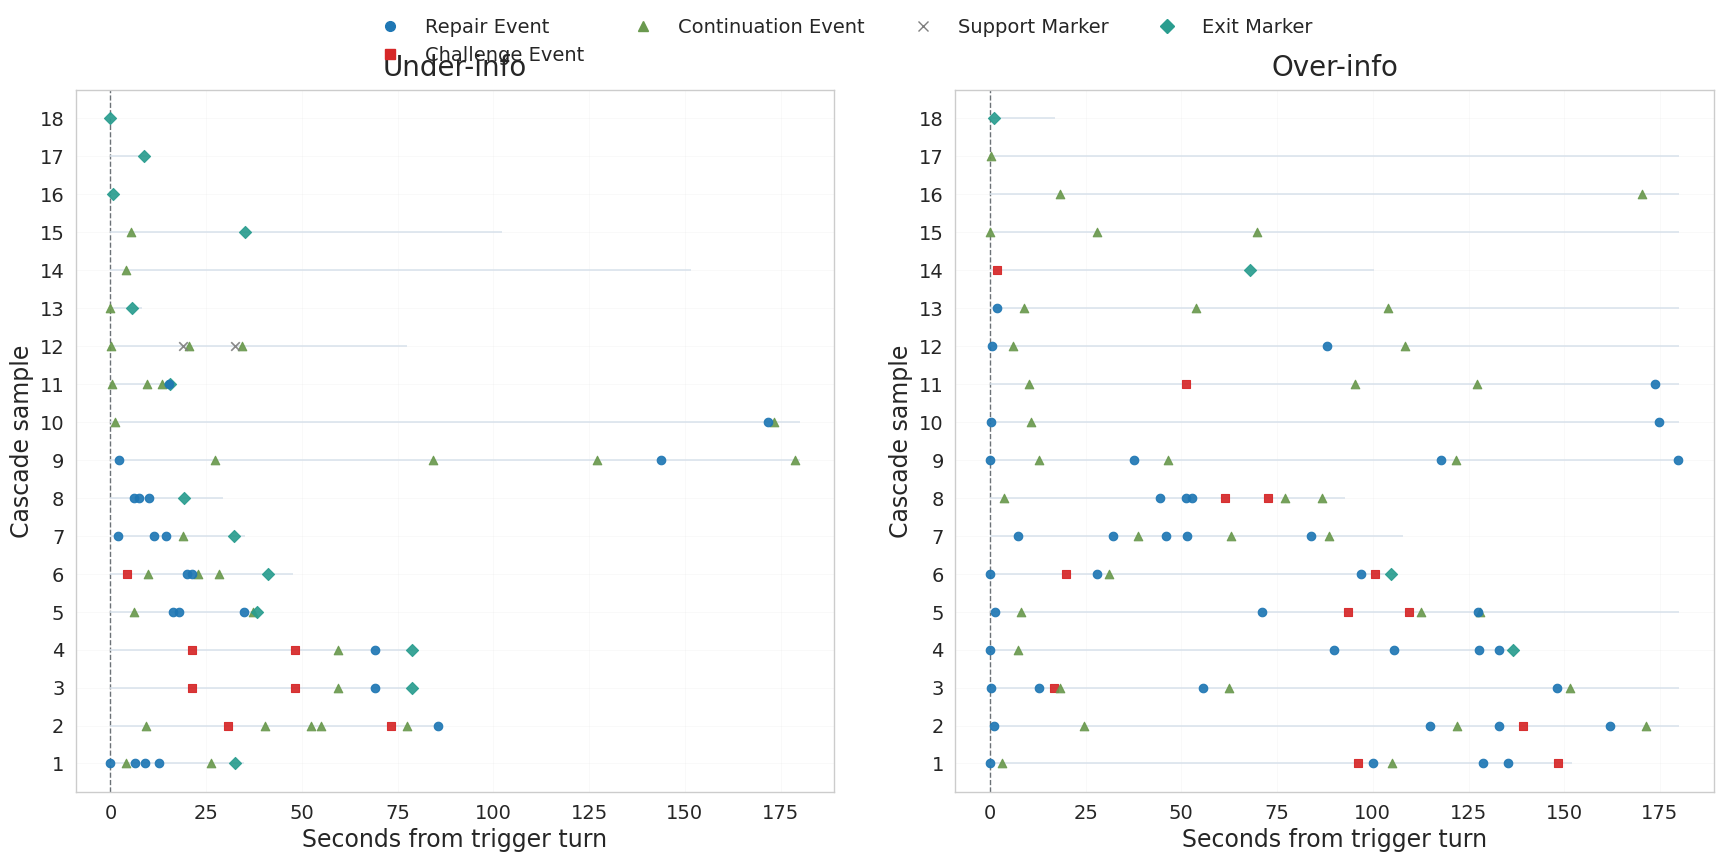

In [13]:
trigger_df = read_csv(EXP6_DIR / "exp6_trigger_outcomes.csv")
event_df = read_csv(EXP6_DIR / "exp6_cascade_events.csv")
hawkes_df = read_csv(EXP6_DIR / "exp6_hawkes_summary.csv")
require_columns(trigger_df, ["trigger_type", "cascade_duration_sec", "repair_event_count", "challenge_event_count", "continuation_event_count", "topic_shift_indicator", "next_turn_latency_sec", "episode_id", "trigger_turn_idx", "observation_horizon_sec"], "Exp6 trigger outcomes")
require_columns(event_df, ["trigger_type", "episode_id", "trigger_turn_idx", "event_type", "relative_start_sec"], "Exp6 cascade events")
require_columns(hawkes_df, ["trigger_type", "branching_ratio", "alpha"], "Exp6 Hawkes summary")

fig, axes = plt.subplots(2, 3, figsize=(16.5, 10.2))
axes = axes.ravel()
x_positions = np.arange(len(EXP6_TRIGGER_ORDER), dtype=float)
labels = [EXP6_TRIGGER_LABELS[trigger_type] for trigger_type in EXP6_TRIGGER_ORDER]
colors = [EXP6_TRIGGER_COLORS[trigger_type] for trigger_type in EXP6_TRIGGER_ORDER]
for axis_index, column_name, title in [(0, "branching_ratio", "Excitation alpha / beta"), (1, "alpha", "Excitation alpha")]:
    values = []
    for trigger_type in EXP6_TRIGGER_ORDER:
        rows = hawkes_df[hawkes_df["trigger_type"] == trigger_type]
        values.append(float(rows[column_name].iloc[0]) if not rows.empty and pd.notna(rows[column_name].iloc[0]) else 0.0)
    axes[axis_index].bar(x_positions, values, color=colors, width=0.62, edgecolor="#1f2933", linewidth=0.6)
    axes[axis_index].set_title(title, fontsize=TITLE_SIZE)
    axes[axis_index].set_xticks(x_positions)
    axes[axis_index].set_xticklabels(labels, fontsize=TICK_SIZE)

metric_specs = [("cascade_duration_sec", "Cascade duration (s)"), ("hawkes_event_count", "Repair/challenge events"), ("topic_shift_indicator", "Topic-shift rate"), ("next_turn_latency_sec", "Next-turn latency (s)")]
for axis, (column_name, axis_title) in zip(axes[2:], metric_specs):
    means = []
    lower_errors = []
    upper_errors = []
    for trigger_type in EXP6_TRIGGER_ORDER:
        group = trigger_df[trigger_df["trigger_type"] == trigger_type]
        if column_name == "hawkes_event_count":
            values = group["repair_event_count"].astype(float).to_numpy() + group["challenge_event_count"].astype(float).to_numpy()
        else:
            values = group[column_name].astype(float).to_numpy()
        values = values[np.isfinite(values)]
        if len(values) == 0:
            mean = 0.0
            ci_low = 0.0
            ci_high = 0.0
        else:
            mean = float(np.mean(values))
            se = float(np.std(values, ddof=1) / math.sqrt(len(values))) if len(values) > 1 else 0.0
            ci_low = mean - 1.96 * se
            ci_high = mean + 1.96 * se
        means.append(mean)
        lower_errors.append(mean - ci_low)
        upper_errors.append(ci_high - mean)
    axis.bar(x_positions, means, color=colors, width=0.62, edgecolor="#1f2933", linewidth=0.6, yerr=np.vstack([lower_errors, upper_errors]), capsize=4)
    axis.set_title(axis_title, fontsize=TITLE_SIZE)
    axis.set_xticks(x_positions)
    axis.set_xticklabels(labels, fontsize=TICK_SIZE)
fig.subplots_adjust(top=0.93, left=0.07, right=0.98, bottom=0.10, wspace=0.32, hspace=0.42)
save_figure(fig, EXP6_DIR / "exp6_cascade_overview.pdf")
plt.show()

def sample_exp6_triggers(trigger_data: pd.DataFrame, trigger_type: str, sample_count: int) -> pd.DataFrame:
    group = trigger_data[trigger_data["trigger_type"] == trigger_type].copy()
    if group.empty:
        return group
    group["hawkes_event_count"] = group["repair_event_count"].astype(int) + group["challenge_event_count"].astype(int)
    ordered = group.sort_values(["hawkes_event_count", "cascade_duration_sec", "continuation_event_count", "episode_id", "trigger_turn_idx"], ascending=[False, False, False, True, True]).reset_index(drop=True)
    if len(ordered) <= sample_count:
        return ordered
    top_count = max(1, sample_count // 2)
    remaining = ordered.iloc[top_count:].copy()
    rng = np.random.default_rng(42)
    selected = rng.choice(len(remaining), size=sample_count - top_count, replace=False)
    return pd.concat([ordered.head(top_count), remaining.iloc[np.sort(selected)]], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(17.8, 9.0), sharex=True)
for axis, trigger_type in zip(axes, EXP6_TRIGGER_ORDER):
    sampled = sample_exp6_triggers(trigger_df, trigger_type, EXP6_SAMPLE_CASCADE_COUNT)
    axis.axvline(0.0, color="#495057", linewidth=1.0, linestyle="--", alpha=0.8)
    axis.set_title(EXP6_TRIGGER_LABELS[trigger_type], fontsize=TITLE_SIZE, pad=10)
    axis.set_xlabel("Seconds from trigger turn", fontsize=LABEL_SIZE)
    axis.set_ylabel("Cascade sample", fontsize=LABEL_SIZE)
    axis.grid(alpha=0.12, linewidth=0.6)
    if sampled.empty:
        raise ValueError(f"No Exp6 sampled triggers for {trigger_type}.")
    for row_position, trigger_row in enumerate(sampled.itertuples(index=False)):
        axis.hlines(y=row_position, xmin=0.0, xmax=float(trigger_row.observation_horizon_sec), color="#d9e2ec", linewidth=1.2, alpha=0.95)
        mask = (event_df["trigger_type"] == trigger_type) & (event_df["episode_id"] == trigger_row.episode_id) & (event_df["trigger_turn_idx"] == trigger_row.trigger_turn_idx)
        for event_type, group in event_df[mask].groupby("event_type", observed=False):
            axis.scatter(group["relative_start_sec"].astype(float).to_numpy(), np.full(len(group), row_position, dtype=float), color=EXP6_EVENT_COLORS[event_type], marker=EXP6_EVENT_MARKERS[event_type], s=38, alpha=0.92, zorder=4)
    axis.set_ylim(-0.75, len(sampled) - 0.25)
    axis.set_yticks(np.arange(len(sampled), dtype=float))
    axis.set_yticklabels([str(index + 1) for index in range(len(sampled))])
handles = [plt.Line2D([0], [0], marker=EXP6_EVENT_MARKERS[event_type], color="none", markerfacecolor=EXP6_EVENT_COLORS[event_type], markeredgecolor=EXP6_EVENT_COLORS[event_type], markersize=7) for event_type in EXP6_EVENT_MARKERS]
labels = [event_type.replace("_", " ").title() for event_type in EXP6_EVENT_MARKERS]
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.98), fontsize=LEGEND_SIZE)
fig.subplots_adjust(top=0.88, left=0.07, right=0.99, bottom=0.10, wspace=0.16)
save_figure(fig, EXP6_DIR / "exp6_event_cascades.pdf")
plt.show()


## Exp 7: Social Power

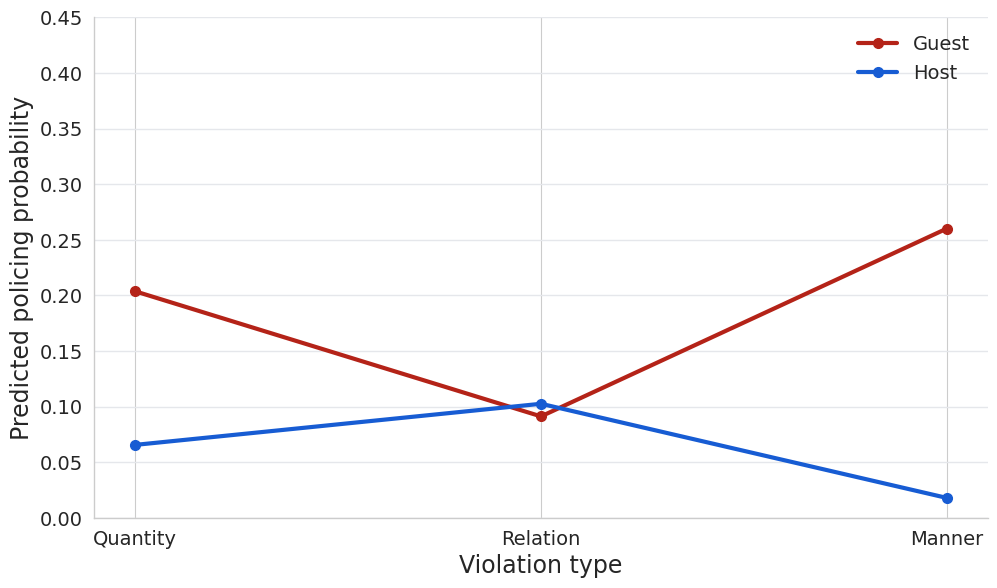

In [8]:
curve_df = read_csv(EXP7_DIR / "exp7_interaction_curve.csv")
require_columns(curve_df, ["speaker_role", "violation_type", "severity", "predicted_policed_probability"], "Exp7 interaction curve")
colors = {"guest": "#b42318", "host": "#175cd3"}
severity_to_label = {EXP7_VIOLATION_SEVERITY[violation]: violation for violation in EXP7_VIOLATION_ORDER}
x_values = [EXP7_VIOLATION_SEVERITY[violation] for violation in EXP7_VIOLATION_ORDER]
fig, ax = plt.subplots(figsize=(10.2, 6.1))
ax.set_facecolor("#ffffff")
ax.grid(axis="y", color="#e5e7eb", linewidth=1.0)
ax.set_axisbelow(True)
for role in EXP7_ROLE_ORDER:
    role_rows = curve_df[curve_df["speaker_role"] == role].sort_values("severity")
    if role_rows.empty:
        raise ValueError(f"Exp7 interaction curve is missing role: {role}")
    ax.plot(role_rows["severity"].astype(int), role_rows["predicted_policed_probability"].astype(float), color=colors[role], linewidth=3.0, marker="o", markersize=7, label=role.title())
ax.set_xlabel("Violation type", fontsize=LABEL_SIZE)
ax.set_ylabel("Predicted policing probability", fontsize=LABEL_SIZE)
ax.set_xticks(x_values)
ax.set_xticklabels([severity_to_label[x_value] for x_value in x_values], fontsize=TICK_SIZE)
probabilities = curve_df["predicted_policed_probability"].astype(float).to_numpy()
max_probability = float(np.nanmax(probabilities)) if len(probabilities) else 0.4
ax.set_ylim(0.0, min(1.0, max(0.45, math.ceil((max_probability + 0.03) * 20.0) / 20.0)))
ax.legend(frameon=False, loc="upper right", fontsize=LEGEND_SIZE)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
save_figure(fig, EXP7_DIR / "exp7_status_shield_plot.pdf")
plt.show()
